In [1]:
import sys
print(sys.executable)
!{sys.executable} -m pip install pandas

C:\Users\sures\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\sures\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
print("hello")


hello


(316, 39) (79, 39)
Logistic Regression Accuracy: 0.7088607594936709
              precision    recall  f1-score   support

           0       0.61      0.41      0.49        27
           1       0.74      0.87      0.80        52

    accuracy                           0.71        79
   macro avg       0.67      0.64      0.64        79
weighted avg       0.69      0.71      0.69        79

[[11 16]
 [ 7 45]]
Random Forest Accuracy: 0.6582278481012658
              precision    recall  f1-score   support

           0       0.50      0.19      0.27        27
           1       0.68      0.90      0.78        52

    accuracy                           0.66        79
   macro avg       0.59      0.54      0.52        79
weighted avg       0.62      0.66      0.60        79

[[ 5 22]
 [ 5 47]]
LR Accuracy: 0.7088607594936709
RF Accuracy: 0.6582278481012658
Accuracy: 0.6582278481012658
              precision    recall  f1-score   support

           0       0.50      0.19      0.27      

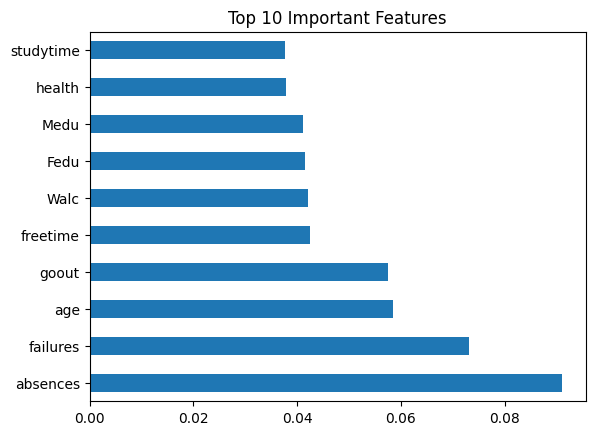

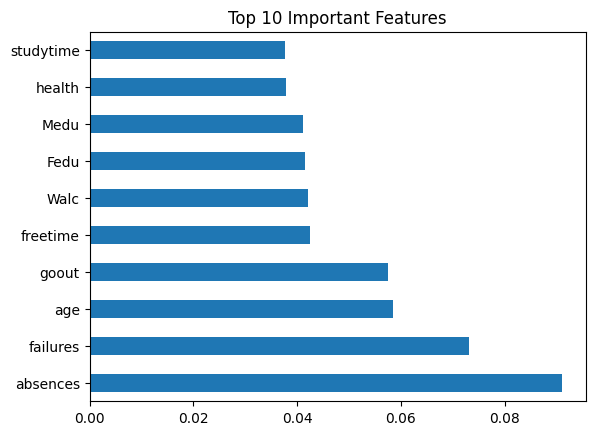

In [20]:
import numpy as np

X_train = np.load("../data/X_train.npy")
X_test  = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_test  = np.load("../data/y_test.npy")

print(X_train.shape, X_test.shape)
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# STEP 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# STEP 2: Load dataset
df = pd.read_csv("../Data/student-mat.csv", sep=';')

# STEP 3: Create target variable
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

# STEP 4: Remove leakage columns
df = df.drop(['G1', 'G2', 'G3'], axis=1)

# STEP 5: Split features & target
X = df.drop('pass', axis=1)
y = df['pass']

# STEP 6: Convert categorical to numerical
X = pd.get_dummies(X, drop_first=True)

# STEP 7: Save feature names (IMPORTANT)
feature_names = X.columns

# STEP 8: Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 9: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# STEP 10: Train model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# STEP 11: Predictions
y_pred = rf.predict(X_test)

# STEP 12: Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# STEP 13: Feature Importance
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()




importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()
import pickle

pickle.dump(rf, open("../model.pkl", "wb"))
import pickle

# Save model
pickle.dump(rf, open("../model/model.pkl", "wb"))

# Save feature column names
pickle.dump(X.columns.tolist(), open("../model/columns.pkl", "wb"))

